In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np



In [2]:
# Use GPU if available, otherwise fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Basic configs
bs = 128      # batch size
z_dim = 100   # latent vector size
lr = 0.0002   # standard DCGAN learning rate
epochs = 20

# Loading MNIST
# DCGAN needs inputs between -1 and 1 because of the Tanh activation at the end of the generator
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(mnist_data, batch_size=bs, shuffle=True)



100%|██████████| 9.91M/9.91M [00:09<00:00, 1.07MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.3MB/s]


In [3]:
# Generator
class Generator(nn.Module):
    def __init__(self, z_dim):
        super(Generator, self).__init__()

        # Project the random noise into a spatial tensor (128 channels, 7x7)
        self.proj = nn.Linear(z_dim, 128 * 7 * 7)

        self.net = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # Upsample 1: 7x7 -> 14x14
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # Upsample 2: 14x14 -> 28x28 (MNIST image size)
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh() # project outputs to [-1, 1]
        )

    def forward(self, x):
        x = self.proj(x)
        x = x.view(-1, 128, 7, 7) # reshape from flat vector to 2D feature maps
        return self.net(x)



In [4]:
# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.net = nn.Sequential(
            # Input: 1 x 28 x 28
            # The DCGAN structure says no batchnorm in the first discriminator layer
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 14 x 14
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 128 x 7 x 7
        )

        # Output a single score (real vs fake)
        self.classifier = nn.Sequential(
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.net(x)
        flat = features.view(features.size(0), -1)
        return self.classifier(flat)

# Instantiate the nets
gen = Generator(z_dim).to(device)
disc = Discriminator().to(device)

In [6]:
loss_fn = nn.BCELoss()

# Keeping a fixed batch of noise so we can watch the generator improve over time on the exact same inputs
fixed_noise = torch.randn(64, z_dim, device=device)


opt_D = optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))
opt_G = optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))

G_losses = []
D_losses = []

print("Starting training")

for epoch in range(epochs):
    for i, (imgs, _) in enumerate(dataloader):

        batch_size = imgs.size(0)
        real_imgs = imgs.to(device)

        # Ground truth labels
        real_labels = torch.ones((batch_size, 1), device=device)
        fake_labels = torch.zeros((batch_size, 1), device=device)


        # 1. Train Discriminator (Maximize log(D(x)) + log(1 - D(G(z))))

        disc.zero_grad()

        # Train on real images
        preds_real = disc(real_imgs)
        loss_D_real = loss_fn(preds_real, real_labels)
        loss_D_real.backward()

        # Train on fake images
        z = torch.randn(batch_size, z_dim, device=device)
        fake_imgs = gen(z)
        preds_fake = disc(fake_imgs.detach()) # detach so we don't backprop into Generator here
        loss_D_fake = loss_fn(preds_fake, fake_labels)
        loss_D_fake.backward()

        opt_D.step()
        loss_D = loss_D_real + loss_D_fake


        # 2. Train Generator (Maximize log(D(G(z))))

        gen.zero_grad()


        preds = disc(fake_imgs)
        loss_G = loss_fn(preds, real_labels)
        loss_G.backward()

        opt_G.step()

        # Save for plotting later
        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

        # Print out progress every 200 batches
        if i % 200 == 0:
            print(f"Epoch [{epoch}/{epochs}] Batch [{i}/{len(dataloader)}] "
                  f"| D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

Starting training
Epoch [0/20] Batch [0/469] | D Loss: 0.2938 | G Loss: 0.6032
Epoch [0/20] Batch [200/469] | D Loss: 0.2909 | G Loss: 1.7384
Epoch [0/20] Batch [400/469] | D Loss: 0.1906 | G Loss: 3.3187
Epoch [1/20] Batch [0/469] | D Loss: 0.1989 | G Loss: 2.7999
Epoch [1/20] Batch [200/469] | D Loss: 0.6173 | G Loss: 0.7093
Epoch [1/20] Batch [400/469] | D Loss: 0.2200 | G Loss: 3.7478
Epoch [2/20] Batch [0/469] | D Loss: 0.3289 | G Loss: 3.2923
Epoch [2/20] Batch [200/469] | D Loss: 0.3193 | G Loss: 2.4406
Epoch [2/20] Batch [400/469] | D Loss: 0.3531 | G Loss: 1.6794
Epoch [3/20] Batch [0/469] | D Loss: 0.2597 | G Loss: 2.9122
Epoch [3/20] Batch [200/469] | D Loss: 0.2247 | G Loss: 3.0952
Epoch [3/20] Batch [400/469] | D Loss: 0.3955 | G Loss: 4.1822
Epoch [4/20] Batch [0/469] | D Loss: 0.2819 | G Loss: 2.8253
Epoch [4/20] Batch [200/469] | D Loss: 0.3722 | G Loss: 2.4383
Epoch [4/20] Batch [400/469] | D Loss: 0.3827 | G Loss: 2.1519
Epoch [5/20] Batch [0/469] | D Loss: 0.2365 | G

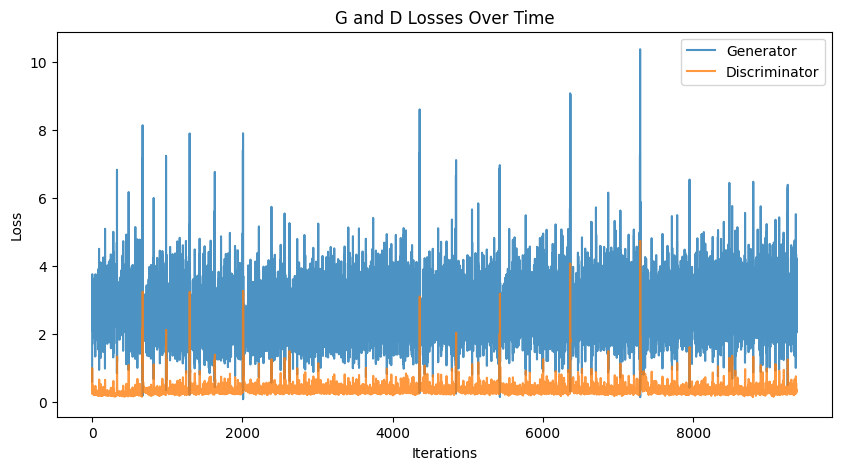

In [7]:
# --- Plot the training losses ---
plt.figure(figsize=(10, 5))
plt.title("G and D Losses Over Time")
plt.plot(G_losses, label="Generator", alpha=0.8)
plt.plot(D_losses, label="Discriminator", alpha=0.8)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()



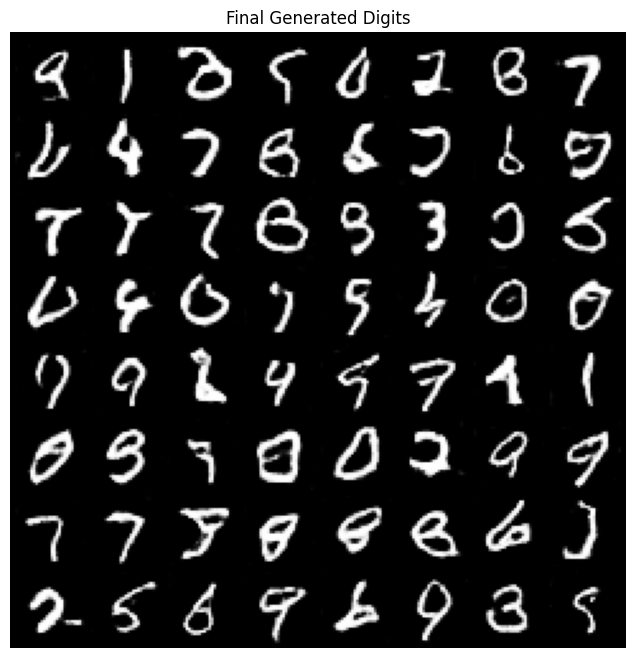

In [8]:
# --- Generate the final image grid ---
gen.eval() # switch to eval mode just to be safe
with torch.no_grad():
    generated_fakes = gen(fixed_noise).cpu()

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Final Generated Digits")
# make_grid handles formatting the batch into a nice square grid automatically
grid = vutils.make_grid(generated_fakes, padding=2, normalize=True)
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.show()

I chose a latent vector size of 100, also the standard for MNIST as it does not produce very blurry images while also does not risk directly copying the data. Since MNIST images are small and simple, I have used only 2 convolutional layers. To avoid the signals to go to either of the extreme ends as they pass through multiple layers, I have used batch normalization everywhere but the discriminator's first layer so that it could have access to the true pixels of real images. LeakyRelu is used in discriminator to  maintain a continuous non-zero gradient flow during backpropagation towards the generator.